In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from scipy.stats import randint

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score, average_precision_score

/Users/samueljoseph/Documents/Programming/Diabetes/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preprocessing Pipeline Plan

- Limit observations to only the first encounter
- Drop additional prescribed medication due to limited clinical relevance
- Conduct feature decomposition on insulin and metformin to include a binary flag for being prescribed the medication and an ordinal encoding for the change
- Create train, validation and test splits
- Preprocess features
    - Convert data types (admission source, admission type)
    - Scale numeric features
    - Encode categoricals (OHE and ordinal)
    - Encode target (multi-class, binary)

## Experimenting with Feature Decomposition

Decomposing the insulin and metformin columns into two each: one binary flag to indicate if someone is on the drug at all, another ordinal encoding encoding if the patient is on the drug to indicate if there was a change in dosing.

In [13]:
features = pd.read_parquet("data/diabetes_features.parquet")
target = pd.read_parquet("data/diabetes_target.parquet")

### Limiting the Data to the First Encounter Only

In [14]:
# Creating a dataframe for selecting first encounters
splitting_df = features.copy()
splitting_df['target'] = (target['readmitted'] == "<30").astype(int)

# Keeping only the first encounter per patient_nbr
split_df = splitting_df.drop_duplicates('patient_nbr', keep='first')

### Preparing Features

Binary and Ordinal Splits for Insulin and Metformin

In [15]:
# Creating a feature to indicate if a patient is not on insulin or metformin
split_df['missing_insulin'] = (split_df.insulin == "No").astype(int)
split_df['missing_metformin'] = (split_df.metformin == "No").astype(int)

# Creating a dictionary to encode changes in insulin and metformin
encode_dict = {'No': 0,
               "Steady": 0,
               "Up": 1,
               "Down": -1}

# Applying the encoding to engineer new features
split_df['metformin_change'] = split_df['metformin'].apply(lambda x: encode_dict[x])
split_df['insulin_change'] = split_df['insulin'].apply(lambda x: encode_dict[x])

Binary missingness encoding for weight

In [16]:
split_df['missing_weight'] = (split_df['weight'] == "?").astype("int")

Binary indicator for missingness to one-hot encode:
- medical_specialty
- payer_code

In [17]:
# Utility function for encoding missing values in a column for one-hot encoding
def missing_cleaner(x, missing_code, encoding=""):
    if x == missing_code:
        return encoding
    else:
        return x

split_df['payer_code_cleaned'] = split_df['payer_code'].apply(missing_cleaner, args=("?", "missing_payer"))
split_df['medical_specialty_cleaned'] = split_df['medical_specialty'].apply(missing_cleaner, args=("?", "missing_medical_specialty"))

Binary indicator and ordinal encoding for A1C and max_glu_serum

In [18]:
split_df['missing_a1c'] = (split_df['A1Cresult'] == "None").astype("int")
split_df['missing_max_glu_serum'] = (split_df['max_glu_serum'] == "None").astype("int")

Adding Interaction Terms

In [19]:
split_df['num_inpatient_interact_time_in_hospital'] = split_df['number_inpatient'] * split_df['time_in_hospital']
split_df['num_inpatient_interact_number_diagnoses'] = split_df['number_inpatient'] * split_df['number_diagnoses']

#### Creating Train and Test Splits

In [20]:
# List of features to drop
drop_features = ['patient_nbr', 'encounter_id', 'target',
                 'repaglinide', 'nateglinide', 'chlorpropamide',
                 'glimepiride', 'acetohexamide', 'glipizide',
                 'glyburide', 'tolbutamide',
                 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
                 'tolazamide', 'examide', 'citoglipton', 'insulin',
                 'glyburide.metformin', 'glipizide.metformin',
                 'glimepiride.pioglitazone', 'metformin.rosiglitazone',
                 'metformin.pioglitazone', 'metformin', 'insulin',
                 'A1Cresult', 'weight', 'diag_1', 'diag_2', 'diag_3',
                 'max_glu_serum', 'change']

# Building X & y dataframes
y = split_df['target']
X = split_df.drop(columns=drop_features)

# Creating train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

## Setting up the Pipeline

Features for scaling:
- time_in_hospital
- num_lab_procedures
- num_procedures
- num_medications
- number_outpatient
- number_inpatient
- number_diagnoses

Features for OHE:
- race
- gender
- admission_type_id
- dicharge_disposition_id
- admission_source_id
- payer_code
- medical_specialty

Features for ordinal encoding:
- Age
- Metformin (already encoded)
- Insulin (already encoded)

#### OHE Columns

In [21]:
OHEFEATURES = ['race', 'gender', 'admission_type_id',
               'discharge_disposition_id', 'admission_source_id',
               'payer_code', 'medical_specialty']

# Pipeline for OHE
ohe_pipeline = Pipeline([('handle_outliers', SimpleImputer(strategy='most_frequent')),
                         ('encoding', OneHotEncoder(handle_unknown='ignore',
                                                    min_frequency=0.01,
                                                    sparse_output=False
                                                    ))])

#### Columns for Scaling

In [22]:
SCALING_FEATURES = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                    'num_medications', 'number_outpatient', 'number_inpatient', 'number_diagnoses']

# Pipeline for Scaling
scaling_pipeline = Pipeline([('scaling', MinMaxScaler())])

#### Columns for Ordinal Encoding

In [23]:
# Setting up a list of columns for ordinal encoding
ORDINAL_COLS = ['age']

# Creating a list of categories for the age column
age_categories = sorted(split_df['age'].unique())

# Setting up a pipeline for ordinal encoding
ordinal_pipeline = Pipeline([('ordinal_encoding', OrdinalEncoder(categories=[age_categories]))])

#### Setting up the Column Transformer

In [24]:
ct = ColumnTransformer([('OHE', ohe_pipeline, OHEFEATURES),
                        ('scaling', scaling_pipeline, SCALING_FEATURES),
                        ('ordinal_encoding', ordinal_pipeline, ORDINAL_COLS)])

# Setting the output to return a pandas dataset
ct.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OHE', ...), ('scaling', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

## Fitting the Model

In [25]:
# Setting up a dictionary of models
models = {'random_forest': RandomForestClassifier(class_weight='balanced'),
          'log_reg': LogisticRegression(),
          'xgboost': GradientBoostingClassifier()}

# Creating the parameter grid
param_grid = {
    'random_forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 5, 10],
        'model__min_samples_split': [2, 5]
    },
    'log_reg': {
        'model__C': np.logspace(-3, 2, 6)
    },
    'xgboost': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': np.linspace(0.1, 1, 4),
        'model__max_depth': [3, 5, 7]
    }
}

# Setting up a scoring dictionary
scoring_dict = {
    'average_precision': 'average_precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'precision': make_scorer(precision_score, zero_division=0)
    }

In [26]:
if True:
    # Setting up a StratifiedKFold for cross-validation
    cv = StratifiedKFold(n_splits=5,
                         random_state=42,
                         shuffle=True)

    # Creating a dictionary for CV results
    cv_results = {}

    # Setting up the loop to evaluate the different models across the parameter grids
    for model_name, model in models.items():

        # Pipeline for model training
        model_training_pipeline = Pipeline([('preprocessing', ct),
                                            ('model', model)])

        # Setting up the grid for CV
        grid = GridSearchCV(model_training_pipeline,
                            param_grid=param_grid[model_name],
                            scoring=scoring_dict,
                            refit='average_precision',
                            cv=cv)

        # Storing the results
        cv_results[model_name] = grid.fit(X_train, y_train)

/Users/samueljoseph/Documents/Programming/Diabetes/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/samueljoseph/Documents/Programming/Diabetes/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as s

In [27]:
if True:    
    results_df = pd.concat(
        {name: pd.DataFrame(grid.cv_results_) for name, grid in cv_results.items()},
        names=['model']
    ).reset_index(level='model')

    # Grabbing the columns I care about
    cols = ['model', 'params', 'mean_test_average_precision',
            'mean_test_recall', 'mean_test_roc_auc', 'rank_test_average_precision']
    results_df[cols].sort_values('mean_test_average_precision', ascending=False)

In [28]:
results_df.to_excel("experiments/model_comparisons.xlsx")

results_df

#### CV Findings:

While Logistic regression produces similar results for average precision, its recall is extraoridarily low. This is not acceptable since recall measures how well the model detects patients that are likely to readmit.

Performance of Random Forest on average precision is best with deeper trees and a smaller number of samples for a split. However, these deep trees have a lower recall than shallow trees, suggesting the model is overfitting. Improved recall with a lower number of samples suggests the model may be learning edge cases for a smaller number of patients, or is subject overfitting.

## Model Refinement

Hyperparameter tuning and feature selection

#### Random Grid Search

In [29]:
# Setting up a new pipeline for hyperparameter tuning
hyperparameter_pipe = Pipeline([('preprocessing', ct),
                                ('model', RandomForestClassifier(
                                    random_state=42,
                                    class_weight='balanced'
                                    ))])

if False:

    # Creating a randomized parameter grid
    rand_hyper_grid = {'model__max_depth': randint(2, 15),
                'model__min_samples_split': randint(2, 10),
                'model__n_estimators': randint(50, 300),
                'model__max_features': ['sqrt', 'log2', 0.3, 0.5]}

    # Setting up a random grid search object
    random_cv = RandomizedSearchCV(estimator=hyperparameter_pipe,
                                cv=5,
                                param_distributions=rand_hyper_grid,
                                n_iter=20,
                                scoring=scoring_dict,
                                random_state=42,
                                refit='recall')

    # Fitting the random grid
    random_cv.fit(X_train, y_train)

In [30]:
if False:
    # Dataframe for CV results
    rand_grid_cv_results = pd.DataFrame(random_cv.cv_results_)

    rand_grid_cv_results.sort_values('mean_test_recall', ascending=False).head(10)

In [31]:
if False:
    sns.relplot(data=rand_grid_cv_results,
                x='mean_test_recall',
                y='mean_test_average_precision',
                hue='param_model__min_samples_split',
                style='param_model__max_features',
                size='param_model__n_estimators')
    plt.title("Average Precision vs Recall for Randomized Search CV")
    plt.show()

In [32]:
if False:
    sns.relplot(data=rand_grid_cv_results,
                x='mean_test_recall',
                y='mean_test_average_precision',
                hue='param_model__max_depth',
                style='param_model__max_features',
                size='param_model__n_estimators')
    plt.title("Average Precision vs Recall for Randomized Search CV")
    plt.show()

#### Random CV Results

- Max depth has a clear impact on model performance: deep trees perform the worst while very shallow trees overfit and precision suffers
- A moderate numbe =r of estimators (~200) provides great recall without a large penalty on precision
- The model performs best with a larger number of parameters (~0.5)
- A high number (~9) of minimum samples per split performs best

#### Regular Grid Search

Searching the smaller space of hyperparameters based on the results from random CV

In [33]:
# Creating a refined hyperparameter grid based on the results of the random search
refined_hyper_grid = {
    'model__max_depth': [5, 6, 7],
    'model__min_samples_split': [8, 9, 10],
    'model__n_estimators': [175, 200, 225],
    'model__max_features': [0.4, 0.5, 0.6]
}

# Running the tune
refined_cv = GridSearchCV(hyperparameter_pipe,
                         cv=5,
                         param_grid=refined_hyper_grid,
                         scoring=scoring_dict,
                         refit='recall',
                         n_jobs=-1)

refined_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 6, ...], 'model__max_features': [0.4, 0.5, ...], 'model__min_samples_split': [8, 9, ...], 'model__n_estimators': [175, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'average_precision': 'average_precision', 'precision': make_scorer(p...ro_division=0), 'recall': 'recall', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None cha

In [34]:
refined_cv_results = pd.DataFrame(refined_cv.cv_results_)
refined_cv_results.to_excel("experiments/refined_cv_results.xlsx", index=False)

In [35]:
refined_cv_results.sort_values('mean_test_recall', ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__max_features,param_model__min_samples_split,param_model__n_estimators,params,split0_test_average_precision,...,std_test_roc_auc,rank_test_roc_auc,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,split4_test_precision,mean_test_precision,std_test_precision,rank_test_precision
20,7.110861,0.067520,0.166800,0.003663,5,0.6,8,225,"{'model__max_depth': 5, 'model__max_features':...",0.157133,...,0.010946,73,0.122649,0.122929,0.127853,0.129078,0.131157,0.126733,0.003390,73
23,7.041118,0.038771,0.171292,0.004311,5,0.6,9,225,"{'model__max_depth': 5, 'model__max_features':...",0.157142,...,0.010943,74,0.122698,0.122904,0.127853,0.129026,0.131157,0.126728,0.003377,74
24,5.574504,0.072567,0.139127,0.004378,5,0.6,10,175,"{'model__max_depth': 5, 'model__max_features':...",0.156755,...,0.010980,80,0.122273,0.122829,0.127832,0.128557,0.131727,0.126644,0.003594,75
18,5.555277,0.062809,0.148887,0.021040,5,0.6,8,175,"{'model__max_depth': 5, 'model__max_features':...",0.156686,...,0.011027,76,0.122322,0.122753,0.127806,0.128557,0.131727,0.126633,0.003596,76
21,5.517033,0.074892,0.136897,0.004663,5,0.6,9,175,"{'model__max_depth': 5, 'model__max_features':...",0.156660,...,0.011035,77,0.122122,0.122753,0.127806,0.128505,0.131727,0.126583,0.003639,79
26,7.092120,0.069318,0.157484,0.004960,5,0.6,10,225,"{'model__max_depth': 5, 'model__max_features':...",0.157318,...,0.010894,75,0.122298,0.122929,0.127879,0.128849,0.131131,0.126617,0.003441,77
25,6.414029,0.143114,0.167423,0.012744,5,0.6,10,200,"{'model__max_depth': 5, 'model__max_features':...",0.156801,...,0.010996,81,0.122343,0.122904,0.127956,0.128739,0.131052,0.126599,0.003407,78
19,6.256879,0.074045,0.152507,0.008741,5,0.6,8,200,"{'model__max_depth': 5, 'model__max_features':...",0.156684,...,0.011047,78,0.122196,0.122854,0.127832,0.128817,0.131079,0.126555,0.003462,80
22,6.295558,0.080331,0.160618,0.020841,5,0.6,9,200,"{'model__max_depth': 5, 'model__max_features':...",0.156696,...,0.011047,79,0.121995,0.122854,0.127832,0.128739,0.131079,0.126500,0.003503,81
11,6.049699,0.088905,0.162096,0.007013,5,0.5,8,225,"{'model__max_depth': 5, 'model__max_features':...",0.158586,...,0.011052,70,0.122222,0.122936,0.128013,0.129130,0.132785,0.127017,0.003959,71


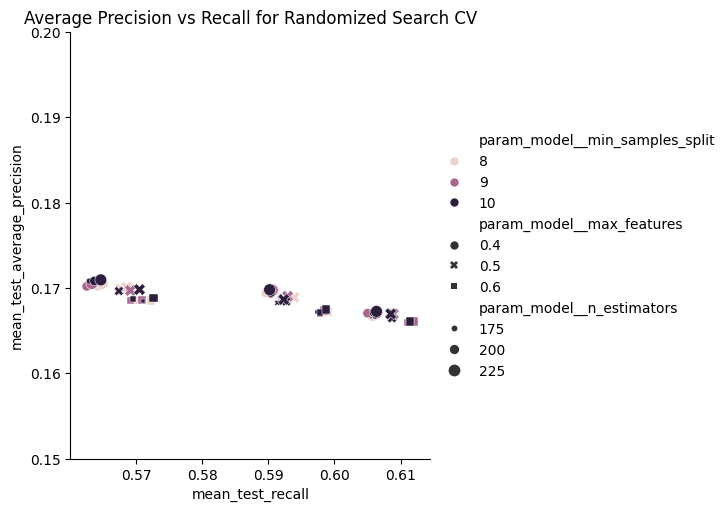

In [36]:
sns.relplot(data=refined_cv_results,
            x='mean_test_recall',
            y='mean_test_average_precision',
            hue='param_model__min_samples_split',
            style='param_model__max_features',
            size='param_model__n_estimators')
plt.title("Average Precision vs Recall for Randomized Search CV")
plt.ylim(0.15, 0.2)
plt.show()

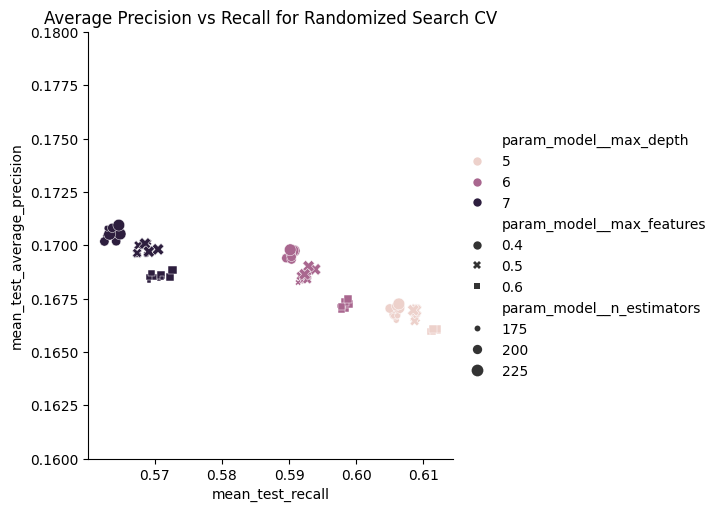

In [37]:
sns.relplot(data=refined_cv_results,
            x='mean_test_recall',
            y='mean_test_average_precision',
            hue='param_model__max_depth',
            style='param_model__max_features',
            size='param_model__n_estimators')
plt.title("Average Precision vs Recall for Randomized Search CV")
plt.ylim(0.16, 0.18)
plt.show()

#### Refitting the Optimal Model

Optimal Parameters:
max_features = 0.6
n_estimators = 200
max_depth = 5
min_samples_split = 10

In [38]:
# Setting up a dict of optimal hyperparameters
optimal_hypers = {
    'max_depth': 5,
    'min_samples_split': 10,
    'n_estimators': 200,
    'max_features': 0.6,
    'class_weight': 'balanced'
}

optimal_rf = RandomForestClassifier(n_jobs=-1,
                                    **optimal_hypers)

optimal_pipeline = Pipeline([('preprocessor', ct),
                             ('model', optimal_rf)])

optimal_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OHE', ...), ('scaling', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

#### Feature Importance

In [39]:
explainer = shap.TreeExplainer(optimal_pipeline['model'])
transformed_x_test = optimal_pipeline[:-1].transform(X_test)
shap_values = explainer.shap_values(transformed_x_test)

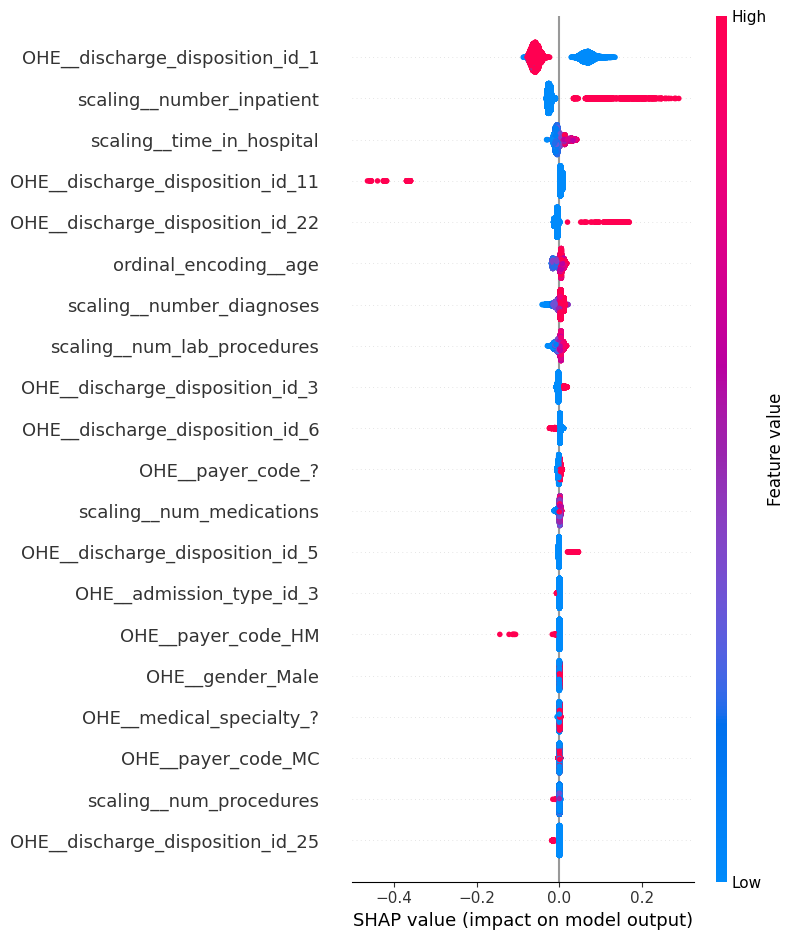

In [40]:
shap.summary_plot(shap_values[:, :, 1], transformed_x_test)

#### Evaluating Performance on The Test Set

Average precision is much lower than the average during validation. False positives will be something to watch when the model is deployed to production.

In [41]:
test_predictions = optimal_pipeline.predict(X_test)

ap_scorer = make_scorer(precision_score, zero_division=0)
test_ap = ap_scorer(optimal_pipeline, X_test, y_test)
test_recall = recall_score(y_test, test_predictions)

In [42]:
print(f"Average Precision for the Test Set: {round(test_ap, 4)}")
print(f"Recall for the Test Set: {round(test_recall, 4)}")

Average Precision for the Test Set: 0.1147
Recall for the Test Set: 0.6057


#### Testing Evaluation Thresholds

In [43]:
y_proba = optimal_pipeline.predict_proba(X_test)[:, 1]
ap = average_precision_score(y_test, y_proba)
print(ap)

0.16659826808786304
